# 8.1 Deep Convolutional Neural Networks (AlexNet)

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## 8.1.1 Representation Learning

### 8.1.1.1. Missing Ingredient: Data

### 8.1.1.2. Missing Ingredient: Hardware

## 8.1.2. AlexNet

### 8.1.2.1. Architecture

### 8.1.2.2. Activation Functions

### 8.1.2.3. Capacity Control and Preprocessing

In [2]:
class AlexNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

In [3]:
AlexNet().layer_summary((1, 1, 224, 224))

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

## 8.1.3 Training

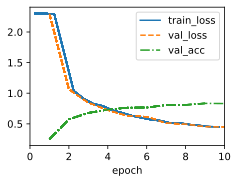

In [4]:
model = AlexNet(lr=0.01)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model, data)

## Ex.1.1 / 1.2

In [6]:
3*96*11*11+96+96*256*5*5+256+256*384*3*3+384+384*384*3*3+384+384*256*3*3+256

3747200

In [45]:
80*80*4096+4096+4096*4096+4096+4096*10+10

43040778

In [75]:
def layer_memory_summary(X_shape, model):
    X = torch.randn(*X_shape)
    params = [0, 0]
    for idx, layer in enumerate(model.net):
        X = layer(X)
        if type(layer) not in (nn.Linear,nn.Conv2d):
            continue
        num = sum(p.numel() for p in layer.parameters())
        print(layer.__class__.__name__, idx, 'Memory usage:\t', num)
        if type(layer) == nn.Conv2d:
            params[0] += num 
        else:
            params[1] += num
    print(f"\nConv layers sum: {params[0]}\nLinear layers sum: {params[1]}")

In [76]:
layer_memory_summary((1, 3, 224, 224), AlexNet(lr=0.01))

Conv2d 0 Memory usage:	 34944
Conv2d 3 Memory usage:	 614656
Conv2d 6 Memory usage:	 885120
Conv2d 8 Memory usage:	 1327488
Conv2d 10 Memory usage:	 884992
Linear 14 Memory usage:	 26218496
Linear 17 Memory usage:	 16781312
Linear 20 Memory usage:	 40970

Conv layers sum: 3747200
Linear layers sum: 43040778


## Ex.4

In [79]:
# model = AlexNet(lr=0.01)
# data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
# trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
# trainer.fit(model, data)

## Ex.5.2

In [88]:
class Net28x28(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(20, kernel_size=5, padding=3),
            nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(84, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),
            nn.LazyConv2d(168, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(512), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(512), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

In [89]:
Net28x28().layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 20, 30, 30])
ReLU output shape:	 torch.Size([1, 20, 30, 30])
MaxPool2d output shape:	 torch.Size([1, 20, 15, 15])
Conv2d output shape:	 torch.Size([1, 84, 14, 14])
ReLU output shape:	 torch.Size([1, 84, 14, 14])
MaxPool2d output shape:	 torch.Size([1, 84, 12, 12])
Conv2d output shape:	 torch.Size([1, 168, 12, 12])
ReLU output shape:	 torch.Size([1, 168, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 512])
ReLU output shape:	 torch.Size([1, 512])
Dropout output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 512])
ReLU output shape:	 torch.Size([1, 512])
Dropout output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


In [90]:
layer_memory_summary((1, 1, 28, 28), Net28x28())

Conv2d 0 Memory usage:	 520
Conv2d 3 Memory usage:	 60564
Conv2d 6 Memory usage:	 127176
Conv2d 8 Memory usage:	 387328
Linear 12 Memory usage:	 3277312
Linear 15 Memory usage:	 262656
Linear 18 Memory usage:	 5130

Conv layers sum: 575588
Linear layers sum: 3545098


#### lr = 0.05

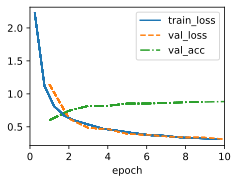

In [91]:
model = Net28x28(lr=0.05)
data = d2l.FashionMNIST(batch_size=128)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model, data)

In [98]:
import statistics

In [107]:
def accuracy_check(model):
    model.eval()
    batch = next(iter(data.get_dataloader(train=False)))
    X = batch[0].to(next(model.parameters()).device)
    Y = batch[1].to(next(model.parameters()).device)
    y_hat = model(X)
    acc = model.accuracy(y_hat, Y).item()
    print(f"Accuracy: {acc:.4f}")

#### lr = 0.1

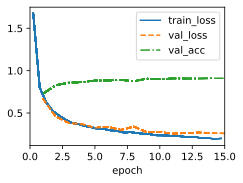

In [94]:
model = Net28x28(lr=0.1)
data = d2l.FashionMNIST(batch_size=128)
trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
trainer.fit(model, data)

In [108]:
accuracy_check(model)

Accuracy: 0.8984


## Ex.6

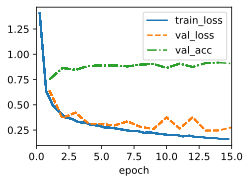

In [111]:
model_batch64 = Net28x28(lr=0.1)
data = d2l.FashionMNIST(batch_size=64)
trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
trainer.fit(model_batch64, data)

In [113]:
accuracy_check(model_batch64)

Accuracy: 0.9062


## Ex.7 

#### Already applied in previous notebook

## Ex.8

#### Yes - the best option is to remove Dropuot 